# Neural Network Models for S&P 500 Return Prediction

This notebook implements and compares **four neural network architectures** for predicting S&P 500 returns using macroeconomic and lagged features.

---

## Models Overview

| Model | Name | Features | Key Technique |
|-------|------|----------|---------------|
| **A** | Baseline NN | `MACRO_COLS` (7 features) | Vanilla feedforward network |
| **B** | NN + L1/L2 Regularisation | `MACRO_COLS` (7 features) | Elastic net penalties on weights |
| **C** | NN + PCA Features | `ALL_COLS` (11 features) | Dimensionality reduction via PCA |

---

## Feature Sets

### `MACRO_COLS` — 7 Macroeconomic Indicators *(Models A, B, C, D)*
| Feature | Description |
|---------|-------------|
| `CPI_Change` | Month-on-month change in Consumer Price Index |
| `Rate_Change` | Change in benchmark interest rate |
| `GDP_Growth` | Quarter-on-quarter GDP growth rate |
| `Unemp_Change` | Change in unemployment rate |
| `USD_Change` | Change in US Dollar index |
| `VIX_Change` | Change in CBOE Volatility Index |
| `Credit_Spread` | Spread between corporate and treasury yields |

### `LAGGED_COLS` — 4 Lagged Signals *(Models C, D only)*
| Feature | Source | Lag |
|---------|--------|-----|
| `CPI_Change_lag1` | `CPI_Change` | t−1 |
| `GDP_Growth_lag2` | `GDP_Growth` | t−2 |
| `Unemp_Change_lag1` | `Unemp_Change` | t−1 |
| `Credit_Spread_lag2` | `Credit_Spread` | t−2 |

> `ALL_COLS = MACRO_COLS + LAGGED_COLS` → **11 total features**

---

## Workflow

1. **Data preparation** — load, clean, and split into train/validation/test sets  
2. **Model A** — establish a performance baseline with 7 macro features  
3. **Model B** — assess the impact of L1/L2 regularisation on generalisation  
4. **Model C** — compress 11 features via PCA before feeding into the network   
5. **Comparison** — evaluate all models on held-out test data  

---

> **Target variable:** S&P 500 forward returns (next period)  
> **Framework:** TensorFlow / Keras  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.optimizers import Adam

import keras_tuner as kt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit


In [2]:
from pathlib import Path
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split


In [ ]:

MACRO_COLS = [
    'CPI_Change', 'Rate_Change', 'GDP_Growth',
    'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread'
]

LAGGED_COLS = [
    'CPI_Change_lag1',
    'GDP_Growth_lag2',
    'Unemp_Change_lag1',
    'Credit_Spread_lag2'
]

ALL_COLS = MACRO_COLS + LAGGED_COLS


df = pd.read_csv('../data/processed/processed_data.csv', parse_dates=['Date'])

splits_data = data_split(df, MACRO_COLS)
X_train_raw = splits_data['X_train']
y_train     = splits_data['y_train']
X_test_raw  = splits_data['X_test']
y_test      = splits_data['y_test']

# Scale — fit on train only
scaler_macro = StandardScaler()
X_train      = scaler_macro.fit_transform(X_train_raw)
X_test       = scaler_macro.transform(X_test_raw)

print(f"\nTrain shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")






  Train       n= 334  1991-03-01 to 2018-12-01  μ=0.58%  σ=4.09%

  Test        n=  81  2019-01-01 to 2025-09-01  μ=1.21%  σ=4.85%

  Features (7): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread

Train shape : (334, 7)
Test  shape : (81, 7)


In [5]:
def get_callbacks(patience=20):
    """Early stopping + learning rate scheduler."""
    return [
        callbacks.EarlyStopping(
            monitor   = 'val_loss',
            patience  = patience,
            restore_best_weights = True,
            verbose   = 1
        ),
        callbacks.ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 10,
            verbose  = 1
        )
    ]

In [6]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    """Compute R², RMSE, MAE, Directional Accuracy for train and test."""

    def metrics(y_true, y_pred):
        return {
            'r2'  : r2_score(y_true, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae' : mean_absolute_error(y_true, y_pred),
            'dir' : np.mean(np.sign(y_pred.flatten()) ==
                            np.sign(y_true.flatten())) * 100
        }

    train_pred = model.predict(X_tr, verbose=0).flatten()
    test_pred  = model.predict(X_te, verbose=0).flatten()

    train_m = metrics(y_tr, train_pred)
    test_m  = metrics(y_te, test_pred)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  {'Metric':<25} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*45}")
    print(f"  {'R²':<25} {train_m['r2']:>10.4f} {test_m['r2']:>10.4f}")
    print(f"  {'RMSE (%)':<25} {train_m['rmse']:>10.3f} {test_m['rmse']:>10.3f}")
    print(f"  {'MAE (%)':<25} {train_m['mae']:>10.3f} {test_m['mae']:>10.3f}")
    print(f"  {'Directional Acc (%)':<25} {train_m['dir']:>10.2f} {test_m['dir']:>10.2f}")

    return train_m, test_m, train_pred, test_pred

In [7]:
def plot_loss_curve(history, model_name):
    """Plot train vs validation loss."""
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'],     label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')

    best_epoch = int(np.argmin(history.history['val_loss'])) + 1
    plt.axvline(best_epoch, color='red', linestyle='--',
                label=f'Best Epoch = {best_epoch}')

    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'{model_name} — Train vs Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()



  Model A — Baseline NN
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.4187     0.2559
  RMSE (%)                       3.117      4.179
  MAE (%)                        2.365      3.229
  Directional Acc (%)            75.15      76.54


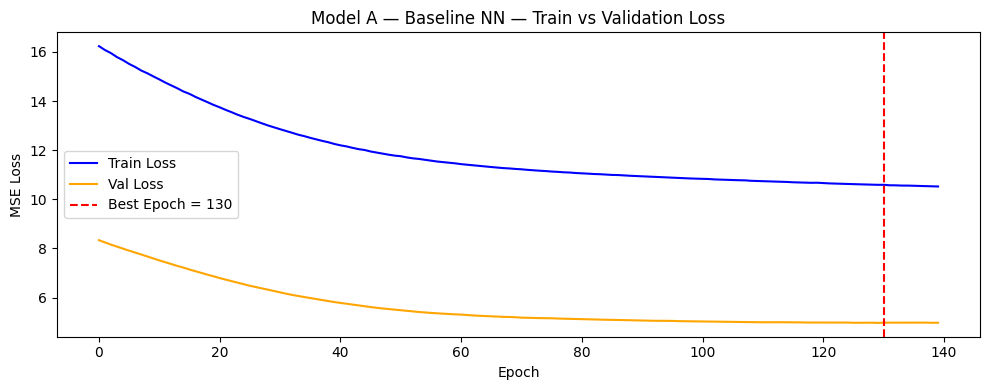

In [10]:

# Model A: Baseline NN

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

def build_baseline(input_size):
    """Simple feedforward NN — no regularization."""
    model = keras.Sequential([
        layers.Input(shape=(input_size,)),
        # layers.Dense(16, activation='relu'),
        layers.Dense(8,  activation='relu'),
        layers.Dense(1)
    ], name='Baseline_NN')

    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

model_a   = build_baseline(X_train.shape[1])
history_a = model_a.fit(
    X_train, y_train,
    validation_split = 0.15,
    epochs           = 300,
    batch_size       = 32,
    callbacks        = [early_stop],
    verbose          = 0
)

train_a, test_a, pred_train_a, pred_test_a = evaluate_model(
    model_a, X_train, y_train, X_test, y_test, 'Model A — Baseline NN'
)

plot_loss_curve(history_a, 'Model A — Baseline NN')



Epoch 153: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 163: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 163: early stopping
Restoring model weights from the end of the best epoch: 143.

  Model B — NN + L1L2 Regularization + Dropout
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3501     0.2967
  RMSE (%)                       3.296      4.063
  MAE (%)                        2.500      3.209
  Directional Acc (%)            73.95      74.07


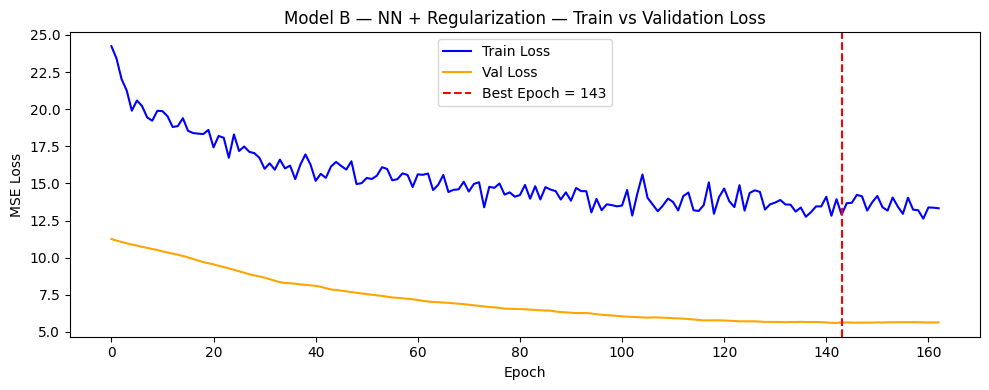

In [11]:
# Model B: NN with regularization + dropout

def build_regularized(input_size, l1=0.001, l2=0.001, dropout=0.3):
    """NN with L1L2 regularization and dropout to reduce overfitting."""
    model = keras.Sequential([
        layers.Input(shape=(input_size,)),

        layers.Dense(16),
        layers.BatchNormalization(),
        layers.Dropout(dropout),

        layers.Dense(8, activation='relu',
                     kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1)
    ], name='Regularized_NN')

    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

model_b   = build_regularized(X_train.shape[1])
history_b = model_b.fit(
    X_train, y_train,
    validation_split = 0.15,
    epochs           = 300,
    batch_size       = 32,
    callbacks        = get_callbacks(patience=20),
    verbose          = 0
)

train_b, test_b, pred_train_b, pred_test_b = evaluate_model(
    model_b, X_train, y_train, X_test, y_test,
    'Model B — NN + L1L2 Regularization + Dropout'
)


plot_loss_curve(history_b, 'Model B — NN + Regularization')


In [12]:
splits_all = data_split(df, ALL_COLS)

#  PCA Features 
X_train_all  = splits_all['X_train']
X_test_all   = splits_all['X_test']

scaler_all   = StandardScaler()
X_train_all  = scaler_all.fit_transform(X_train_all)
X_test_all   = scaler_all.transform(X_test_all)


# PCA on lagged cols only — retain 95% variance
n_lag        = len(LAGGED_COLS)
X_train_lag  = X_train_all[:, len(MACRO_COLS):]
X_test_lag   = X_test_all[:,  len(MACRO_COLS):]

pca          = PCA(n_components=0.95, random_state=42)
X_train_pca  = pca.fit_transform(X_train_lag)
X_test_pca   = pca.transform(X_test_lag)

n_pca        = X_train_pca.shape[1]
print(f"\nPCA: {n_lag} lag features  {n_pca} components ")

# Combine macro + PCA components
X_train_c    = np.hstack([X_train, X_train_pca])
X_test_c     = np.hstack([X_test,  X_test_pca])


  Train       n= 334  1991-03-01 to 2018-12-01  μ=0.58%  σ=4.09%

  Test        n=  81  2019-01-01 to 2025-09-01  μ=1.21%  σ=4.85%

  Features (11): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread, CPI_Change_lag1, GDP_Growth_lag2, Unemp_Change_lag1, Credit_Spread_lag2

PCA: 4 lag features  4 components 



Epoch 179: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 189: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 189: early stopping
Restoring model weights from the end of the best epoch: 169.

  Model C — NN + PCA Features
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.5073    -2.0043
  RMSE (%)                       2.870      8.398
  MAE (%)                        2.181      4.396
  Directional Acc (%)            77.84      71.60


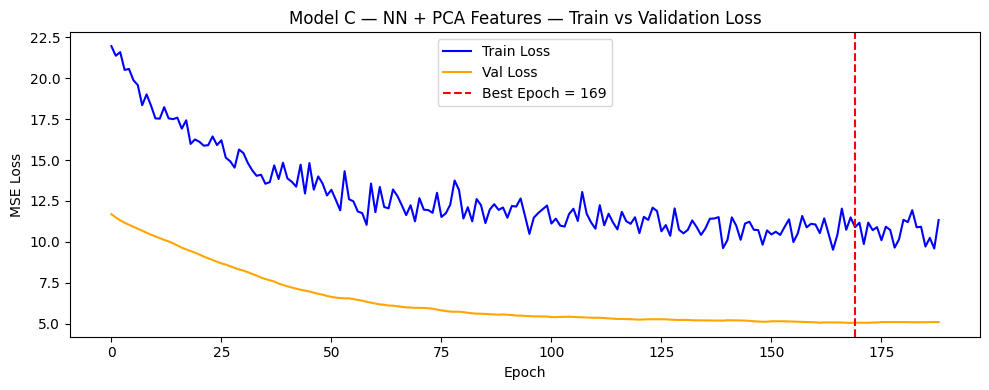

In [16]:
# Model C: NN with PCA features

def build_pca_model(input_size):
    """NN using macro features + PCA-compressed lag features."""
    model = keras.Sequential([
        layers.Input(shape=(input_size,)),

        layers.Dense(16, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(8, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.2),
        layers.Dense(1)
    ], name='PCA_NN')

    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

model_c   = build_pca_model(X_train_c.shape[1])
history_c = model_c.fit(
    X_train_c, y_train,
    validation_split = 0.15,
    epochs           = 300,
    batch_size       = 32,
    callbacks        = get_callbacks(patience=20),
    verbose          = 0
)

train_c, test_c, pred_train_c, pred_test_c = evaluate_model(
    model_c, X_train_c, y_train, X_test_c, y_test,
    'Model C — NN + PCA Features'
)

plot_loss_curve(history_c, 'Model C — NN + PCA Features')
